# Homework 6

## Petersen Graph



In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import itertools

### The graph

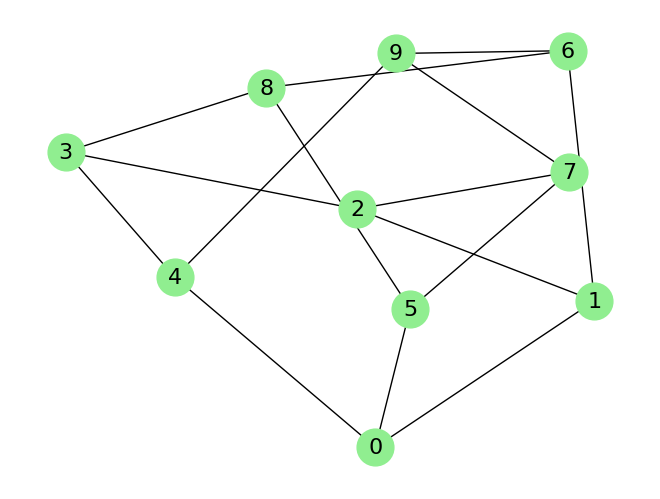

In [7]:
# Create Petersen graph
G = nx.petersen_graph()

# Draw the graph with spring layout
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels = True, node_color = 'lightgreen', edge_color = 'black', node_size = 700, font_size = 16)

plt.show()

Every time this version of the code is run, dew to a random seed, the graph layout is always different. Below is the version as seen on wikipedia.

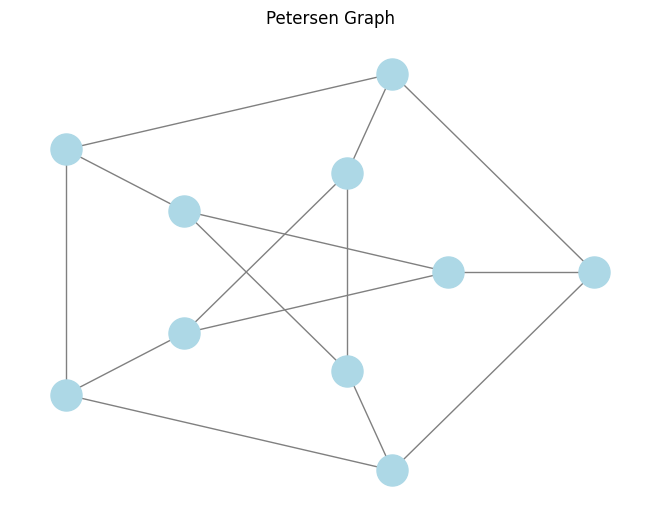

In [8]:
outer_nodes = [0, 1, 2, 3, 4] # Outer pentagon nodes
inner_nodes = [5, 6, 7, 8, 9] # Inner star nodes

outer_pos = nx.circular_layout(G.subgraph(outer_nodes), scale = 2)
inner_pos = nx.circular_layout(G.subgraph(inner_nodes), scale = 1)

pos = {**outer_pos, **inner_pos} # Combine positions

nx.draw(G, pos, with_labels = False, node_color = 'lightblue', edge_color = 'gray', node_size = 500, font_size = 15)
plt.title("Petersen Graph")
plt.show()

The Petersen graph is an undirected graph with 10 vertices and 15 edges.

### Diameter

The diameter of a graph is the maximum of the distance between pairs of vertices

In [9]:
diameter = nx.diameter(G)
print(f"The diameter of the graph is: {diameter}")

The diameter of the graph is: 2


Here's a visual representation

<function matplotlib.pyplot.show(close=None, block=None)>

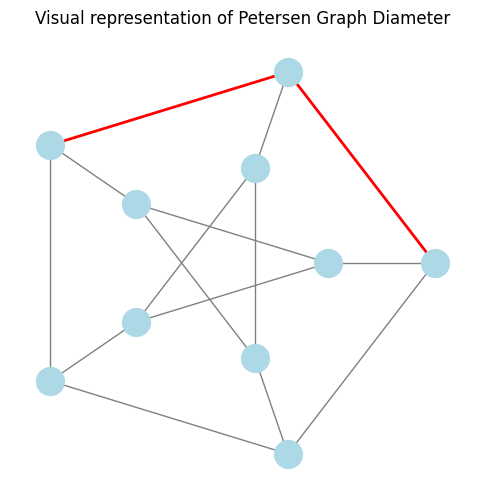

In [21]:
# Find all node pairs equal in distance to diameter
diameter_pairs = [(u, v) for u in G.nodes() for v in G.nodes() if nx.shortest_path_length(G, u, v) == diameter]

u, v = diameter_pairs[0] # Select initial pair
path = nx.shortest_path(G, u, v)

# Outer pentagon nodes (0, 1, 2, 3, 4)
outer_radius = 1
outer_angles = np.linspace(0, 2 * np.pi, 6)[:-1] # 120º = 2*pi/5
outer_pos = {
    i: (outer_radius * np.cos(angle), outer_radius * np.sin(angle))
    for i, angle in enumerate(outer_angles)
}

# Inner star nodes (5, 6, 7, 8, 9)
inner_radius = 0.5
inner_angles = np.linspace(0, 2 * np.pi, 6)[:-1]
inner_pos = {
    i + 5: (inner_radius * np.cos(angle), inner_radius *  np.sin(angle))
    for i, angle in enumerate(inner_angles)
}

pos = {**outer_pos, **inner_pos}

plt.figure(figsize = (6, 6))
nx.draw_networkx_nodes(G, pos, node_color = 'lightblue', node_size = 400)
nx.draw_networkx_edges(G, pos, edge_color = 'gray')

# Highlight diameter path
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist = path_edges, edge_color = 'red', width = 2)

plt.title(f"Visual representation of Petersen Graph Diameter")
plt.axis('off')
plt.show

### Girth

The girth of a graph is the length of the shortest polygon in the graph. Note that for acyclic graphs, the girth is difined as infinty.

In [11]:
girth = nx.girth(G)
print(f"The girth of the graph is {girth}")

The girth of the graph is 5


Here's a visual representation

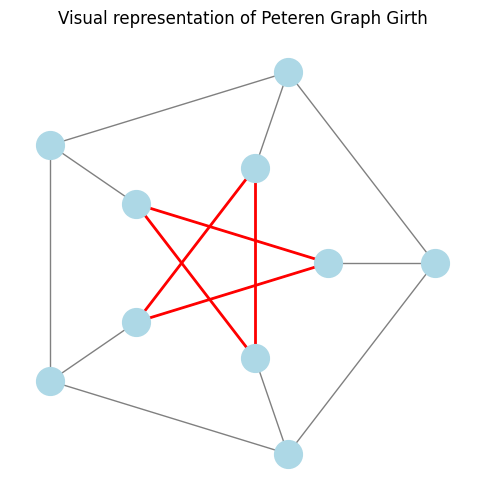

In [22]:
# Get edges from cycle
shortest_cycles = [cycle for cycle in nx.cycle_basis(G) if len(cycle) == girth]

if shortest_cycles:
    shortest_cycle = shortest_cycles[0] # Pick initial cycle
    cycle_edges = list(zip(shortest_cycle, shortest_cycle[1:] + [shortest_cycle[0]])) # Get edges of cycle
else:
    print("The graph is acyclic.")
    exit()

# Outer pentagon nodes (0, 1, 2, 3, 4)
outer_radius = 1
outer_angles = np.linspace(0, 2 * np.pi, 6)[:-1] # 120º = 2*pi/5
outer_pos = {
    i: (outer_radius * np.cos(angle), outer_radius * np.sin(angle))
    for i, angle in enumerate(outer_angles)
}

# Inner star nodes (5, 6, 7, 8, 9)
inner_radius = 0.5
inner_angles = np.linspace(0, 2 * np.pi, 6)[:-1]
inner_pos = {
    i + 5: (inner_radius * np.cos(angle), inner_radius *  np.sin(angle))
    for i, angle in enumerate(inner_angles)
}

pos = {**outer_pos, **inner_pos}

plt.figure(figsize = (6, 6))
nx.draw_networkx_nodes(G, pos, node_color = 'lightblue', node_size = 400)
nx.draw_networkx_edges(G, pos, edge_color = 'gray')

#Highlight shortest cycle
nx.draw_networkx_edges(G, pos, edgelist = cycle_edges, edge_color = 'red', width = 2)

plt.title(f"Visual representation of Peteren Graph Girth")
plt.axis('off')
plt.show()


### Automorphisms

An automorphism is a symmetry of a graph, or a rearrangement of the graph's nodes that preserves the structure of the graph.

In [13]:
def automorphisms(graph):
    return list(nx.algorithms.isomorphism.GraphMatcher(graph, graph).isomorphisms_iter())

auto_list = automorphisms(G)
print("Automorphisms of Petersen Graph:", len(auto_list))

Automorphisms of Petersen Graph: 120


### chromatic number

The chromatic number refers to the minimum number of colours needed to colour the vertices of a graph such that no two adjacent vertices share the same colour. This is known as proper vertex colouring.

Valid vertex colouring found for k = 3
Chromatic Number of Petersen Graph: 3


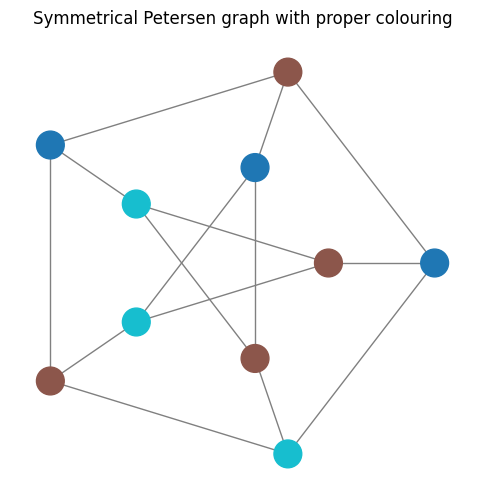

In [4]:
# Code using a brute-force method

def is_valid_vertex_coloring(graph, vertex_colors):
    """Checks if no two adjacent vertices have the same colour"""
    for u, v in graph.edges():
        if vertex_colors[u] == vertex_colors[v]:
            return False
    return True

def chromatic_index_brute_force(graph, max_k = 4):
    """Uses brute-force method for vertex colouring"""
    nodes = list(graph.nodes())
    for k in range(2, max_k + 1):
        # Generate all possible colour combinations
        for color_combination in itertools.product(range(k), repeat = len(nodes)):
            vertex_colors = dict(zip(nodes, color_combination))
            if is_valid_vertex_coloring(graph, vertex_colors):
                print(f"Valid vertex colouring found for k = {k}")
                return k, vertex_colors
    return None, None

G = nx.petersen_graph()

chrom_num, vertex_colors = chromatic_index_brute_force(G, max_k = 3)

if chrom_num is not None:
    print(f"Chromatic Number of Petersen Graph: {chrom_num}")
else:
    print("No valid vertex colouring found for k <= 3")

outer_radius = 1
outer_angles = np.linspace(0, 2 * np.pi, 6)[:-1]
outer_pos = {
    i: (outer_radius * np.cos(angle), outer_radius * np.sin(angle))
    for i, angle in enumerate(outer_angles)
}

inner_radius = 0.5
inner_angles = outer_angles
inner_pos = {
    i + 5: (inner_radius * np.cos(angle), inner_radius * np.sin(angle))
    for i, angle in enumerate(inner_angles)
}

pos = {**outer_pos, **inner_pos}

plt.figure(figsize = (6, 6))
nx.draw_networkx_nodes(G, pos, node_color = [vertex_colors[v] for v in G.nodes()], cmap = plt.cm.tab10, node_size = 400)
nx.draw_networkx_edges(G, pos, edge_color = 'gray', width = 1)
plt.title("Symmetrical Petersen graph with proper colouring")
plt.axis('off')
plt.show()

To brute-force a problem like this we have to check every possible colour-vertex combination for a constant colouring index, k. If the initial value k = 2 isn't able to succesfully perform proper colouring, we increase it by one and try again. In this code:

- **is_valid_vertex_colouring()** checks if no two neighbouring vertices share a colour for all edges.

- **chromatic_number_brute_force** tests all possible colour combinations from k = 2 to max_k (which can have a buffer for redundancy's sake). This is done using <ins>itertools.product</ins>, which generates the colour assignments.

Although, it should be stated that this method only for works due to the Petersen graph's considerably low number of vertices.

Now we compare it using networkx's greedy colour function.

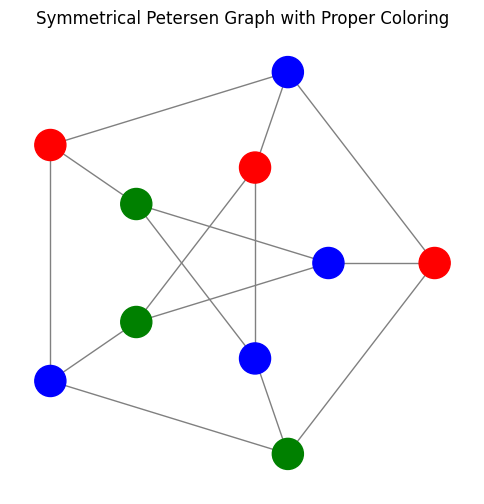

In [ ]:
# Code using greedy colour 

def plot_colored_graph(graph, pos, title):
    coloring = nx.coloring.greedy_color(graph, strategy="largest_first")
    
    # Map colors to actual color names or codes
    color_map = []
    for node in graph.nodes():
        if coloring[node] == 0:
            color_map.append("red")
        elif coloring[node] == 1:
            color_map.append("blue")
        elif coloring[node] == 2:
            color_map.append("green")
        elif coloring[node] == 3:
            color_map.append("yellow")
        else:
            color_map.append("purple")  # Fallback for more colors
    
    plt.figure(figsize=(6, 6))
    nx.draw_networkx_nodes(graph, pos, node_color=color_map, node_size=500)
    nx.draw_networkx_edges(graph, pos, edge_color="gray")
    
    plt.title(title)
    plt.axis("off")
    plt.show()

G = nx.petersen_graph()

# Outer pentagon nodes (0, 1, 2, 3, 4)
outer_radius = 1
outer_angles = np.linspace(0, 2 * np.pi, 6)[:-1]  # 120º = 2*pi/5
outer_pos = {
    i: (outer_radius * np.cos(angle), outer_radius * np.sin(angle))
    for i, angle in enumerate(outer_angles)
}

# Inner star nodes (5, 6, 7, 8, 9)
inner_radius = 0.5
inner_angles = np.linspace(0, 2 * np.pi, 6)[:-1]
inner_pos = {
    i + 5: (inner_radius * np.cos(angle), inner_radius * np.sin(angle))
    for i, angle in enumerate(inner_angles)
}

# Combine the positions
pos = {**outer_pos, **inner_pos}

# Plot the Petersen graph with proper coloring
plot_colored_graph(G, pos, "Symmetrical Petersen Graph with Proper Coloring")


As we can see, the Petersen Graph's chromatic number is, in fact, 3.

### Chromatic index

The chromatic index, or edge colouring, of a graph is the smallest number of colours needed to colur the edges of the graph such that no two adjacent edges share the same colour.

No valid edge coloring found for k < 4


AttributeError: 'NoneType' object has no attribute 'items'

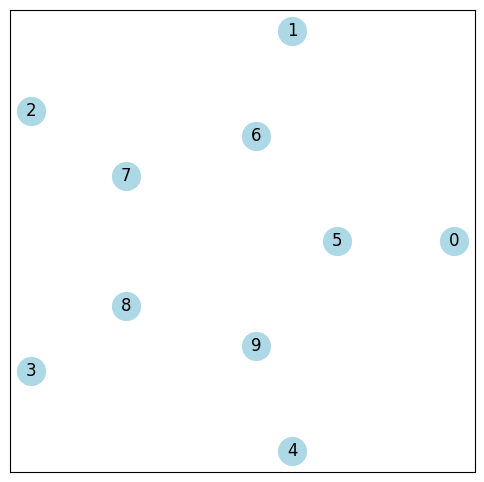

In [ ]:
def is_valid_edge_coloring(graph, edge_colors):
    """Check if no two adjacent edges share the same color."""
    for node in graph.nodes():
        adjacent_edges = list(graph.edges(node))
        adjacent_colors = []
        for edge in adjacent_edges:
            if edge in edge_colors:
                adjacent_colors.append(edge_colors[edge])
            elif (edge[1], edge[0]) in edge_colors:  # Handle undirected edges
                adjacent_colors.append(edge_colors[(edge[1], edge[0])])
        if len(adjacent_colors) != len(set(adjacent_colors)):
            return False
    return True

def chromatic_index_brute_force(graph, max_k=3):
    """Brute-force search for the chromatic index (edge coloring)."""
    edges = list(graph.edges())
    for k in range(1, max_k + 1):
        # Generate all possible color combinations for edges (k colors)
        for color_combination in itertools.product(range(k), repeat=len(edges)):
            edge_colors = dict(zip(edges, color_combination))
            if is_valid_edge_coloring(graph, edge_colors):
                print(f"Found valid edge coloring with k = {k}")
                return k, edge_colors
    return None, None

G = nx.petersen_graph()

chrom_idx, edge_colors = chromatic_index_brute_force(G, max_k=3)

if chrom_idx is not None:
    print(f"Chromatic Index of the Petersen Graph: {chrom_idx}")
else:
    print("No valid edge coloring found for k < 4")

outer_radius = 1
outer_angles = np.linspace(0, 2 * np.pi, 6)[:-1]  
outer_pos = {
    i: (outer_radius * np.cos(angle), outer_radius * np.sin(angle))
    for i, angle in enumerate(outer_angles)
}

inner_radius = 0.5
inner_angles = outer_angles  
inner_pos = {
    i + 5: (inner_radius * np.cos(angle), inner_radius * np.sin(angle))
    for i, angle in enumerate(inner_angles)
}

pos = {**outer_pos, **inner_pos}

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=400)
nx.draw_networkx_labels(G, pos, font_size=12)

color_map = {0: "red", 1: "blue", 2: "green", 3: "yellow"}
for edge, color_idx in edge_colors.items():
    nx.draw_networkx_edges(G, pos, edgelist=[edge], edge_color=color_map[color_idx], width=2)

plt.title(f"Petersen Graph: Edge Coloring (Chromatic Index = {chrom_idx})")
plt.axis("off")
plt.show()

Above is the brute-force version of the code. Unfortunately, due to the nature of this kind of approach, when we have over $15^4$ possible combinations it becomes extremely difficult for a normal computer to run this type of program.
I ran into issues while trying to run the code with k = 4. So I've altered max_k to k = 3 to show that the code itself does work. 

As we know, it's impossible to perform proper edge-colouring on the Petersen Graph with just 3 colours, which is the result given by the code.

The rational behind the first two functions is exactly the same as for the chromatic number, except now we apply that logic to the edges as opposed to the vertices.

Below is the version using networkx's greedy colouring function.

Chromatic Index of the Petersen Graph: 4


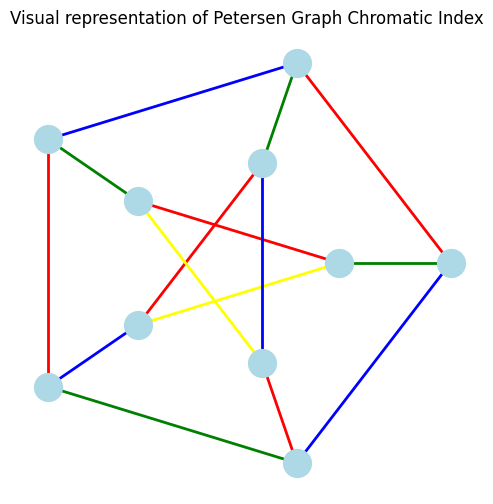

In [5]:
def edge_coloring(graph):
    edge_colors = {}  # Dictionary to store edge colors
    available_colors = set()  # Set to track available colors for each edge
    
    # Iterate over all edges in the graph
    for edge in graph.edges():
        # Find the colors used by adjacent edges
        used_colors = set()
        for neighbor in graph.neighbors(edge[0]):
            if (edge[0], neighbor) in edge_colors:
                used_colors.add(edge_colors[(edge[0], neighbor)])
            if (neighbor, edge[0]) in edge_colors:
                used_colors.add(edge_colors[(neighbor, edge[0])])
        for neighbor in graph.neighbors(edge[1]):
            if (edge[1], neighbor) in edge_colors:
                used_colors.add(edge_colors[(edge[1], neighbor)])
            if (neighbor, edge[1]) in edge_colors:
                used_colors.add(edge_colors[(neighbor, edge[1])])
        
        # Assign the smallest available color
        color = 0
        while color in used_colors:
            color += 1
        edge_colors[edge] = color
    
    return edge_colors

def chromatic_index(graph):
    edge_colors = edge_coloring(graph)
    num_colors = max(edge_colors.values()) + 1  # Colors are 0-indexed
    return num_colors

edge_colors = edge_coloring(G)

chrom_idx = chromatic_index(G)
print(f"Chromatic Index of the Petersen Graph: {chrom_idx}")

# Outer pentagon nodes (0, 1, 2, 3, 4)
outer_radius = 1
outer_angles = np.linspace(0, 2 * np.pi, 6)[:-1] 
outer_pos = {
    i: (outer_radius * np.cos(angle), outer_radius * np.sin(angle))
    for i, angle in enumerate(outer_angles)
}

# Inner star nodes (5, 6, 7, 8, 9)
inner_radius = 0.5
inner_angles = np.linspace(0, 2 * np.pi, 6)[:-1]
inner_pos = {
    i + 5: (inner_radius * np.cos(angle), inner_radius * np.sin(angle))
    for i, angle in enumerate(inner_angles)
}

pos = {**outer_pos, **inner_pos}

# Map edge colors to actual color names
color_map = {0: "red", 1: "blue", 2: "green", 3: "yellow"}

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=400)

# Draw edges with their assigned colors
for edge, color_index in edge_colors.items():
    nx.draw_networkx_edges(G, pos, edgelist=[edge], edge_color=color_map[color_index], width=2)

plt.title(f"Visual representation of Petersen Graph Chromatic Index")
plt.axis("off")
plt.show()